# Condensator Ontwerpopdracht

Bij het vak elektromagnetisme zullen jullie in de eerste paar weken diep ingaan op de elektrostatica. Parallel hieraan zullen we bij het vak DEF-D, naast de fysieke ontwerpopdrachten en colleges, deze simulatie-ontwerpopdracht behandelen. Deze simulatie-opdracht is weer nauw verwoven met de tweede fysieke ontwerpopdracht die in week 3.3 gegeven wordt. Je moet het grootste deel van deze simulatie opdracht afronden voordat je aan de fysieke ontwerpopdracht van week 3.3 begint. Het laatste stuk van deze simulatie opdracht maak je na afloop van de fysieke opdracht. De deadline voor het inleveren van deze simulatie-opdracht is in week 3.4

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

In deze simulatie opdracht beginnen we met een aantal simulaties van verschillende situaties, die jullie daarna zullen interpreteren. Daarna zal wat essentiële voorbereiding op de tweede fysieke ontwerpopdracht besproken worden. En als laatste zal dieper ingegaan worden op hoe jullie metingen van de tweede ontwerpopdracht afwijken van de theorie.

De opdracht bestaat uit de volgende sub-opdrachten die je moet doen voordat je begint aan de fysieke ontwerpopdracht van week 3.3:
1) Een puntlading in de oorsprong.
2) Een uniform geladen schijf bestaande uit puntladingen.
3) Een geladen schijf op een constant potentiaal.
4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$.
5) Voorbereidende opdracht voor de DEF ontwerpopdracht.

Na de fysieke ontwerpopdracht van week 3.3 kan je ten slotte het laatste deel doen:

6) Reflectie opdracht voor na de fysieke ontwerpopdracht.

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.4 beoordeeld en herkansingen zijn in week 3.5, zie de studiehandleiding voor details.
   
Technische Instructies:
- Git clone (als nog niet gedaan) het DEF repo en maak een branch voor werken aan deze opdracht. Nodig je groepsgenoot uit als collaborator. Hiervoor staat een manual op brightspace.
- Dit notebook maakt gebruik van een aantal functies die in het bestand ```functions_electrostatics.py``` staan. Dit bestand moet in dezelfde map (folder) staan als dit notebook. Als je git clone doet, gaat dat automatisch goed, maar verplaats dit notebook dus niet naar een andere map, mail het niet naar een mede-student, etc. Als je niet weet wat een map (folder) en een bestand is, bekijk dan [deze tutorial](https://teachbooks.io/files-and-folders/EN/intro.html).

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Bij elke code cel staat aangegeven of jij hem moet aanpassen of alleen runnen. Lees bij cellen die je moet runnen, maar niet hoeft aan te passen, goed de code door om daarvan te leren en te gebruiken in de cellen die je wel moet aanpassen.

Elektrostatica Opmerkingen:
- In deze opdracht zullen jullie verschillende problemen bestuderen die as-symmetrie hebben. De opdrachten zullen daardoor, cilindrische coördinaten ($r$,$\phi$,$z$) gebruiken, waarbij $r$ de afstand tot de $z$ as is, $z$ de hoogte en $\phi$ de hoek met de $x$-as. Alle gebruikte problemen zullen ook in de $\phi$ richting symmetrisch zijn en die coördinaat zal dus niet uitmaken.
- Voor elke sub-opdracht zal eerst het potentiaal bepaald worden en daarna zal het elektrische veld bepaald worden met de "finite difference" methode. Dit is een methode om de afgeleide te nemen van een dataset. Deze methode is geen onderdeel van de leerdoelen van het vak en komt later in je studie aan bod. We gebruiken "finite difference" hier als gereedschap en als voorbeeld van wat je later nog tegen gaat komen.



Vul de informatie in deze cel in:

| Groep: 48     |  |
| Groep: 48       |  |
| :-------------|:-------------|
| Alexander Boerefijn| 6468624 |
| Florian Spauwen| 6582303 |

In [1]:
# Run deze cel, pas deze niet aan
import numpy as np
import matplotlib.pyplot as plt
from functions_electrostatics import *
#from IPython import display
from IPython.display import Image, display
from scipy.optimize import curve_fit

epsilon0 = 8.854e-12  # permittiviteit van vacuum (F/m)

"""============================================================================================
We first define the size of the domain of calculation and spatial discretization of the domain
"""

# Grid van het rekendomein; het veld wordt berekend in het (r,z)-vlak (asymmetrie):
width_domain = 5  # (m)
height_domain = width_domain  # maximum afstand van de schijf tot de grond, boven en beneden (m)
grid_step = 0.1  # grid stap grootte (m)

### 1) Een puntlading in de oorsprong

In deze opdracht gaan we in op een numerieke benadering van het potentiaal en elektrische veld rond een puntlading in de oorsprong. 

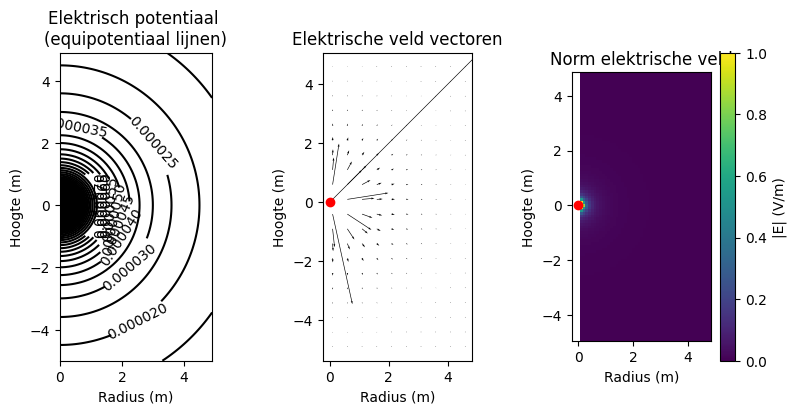

In [2]:
# Run deze cel, pas de cel niet aan
charge_one_point = 1e-14  # lading van 1 punt (C)

r, z, B = initialize_plane_grid_for_pt_charge_at_origin(height_domain, width_domain, grid_step)
V = calculate_V_point_charge_at_origin(charge_one_point, r, z)

Er, Ez, normE = compute_E_pt_charge(V, B, grid_step)  # gebruik de centered finite-difference method
# met Er de r-component, Ez de z-component en normE de norm van het elektrische veld

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_pt_charge_at_origin(Ez, Er, normE, V, r, z, grid_step)


##### Vraag 1a Het potentiaal rond een puntlading

1. Bepaal welke index correspondeert met $z = 0$ m.
2. Plot de log van het potentiaal tegen de log van de straal.
3. Fit de log van het potentiaal met de log van de straal.
4. Print het exponent op een nette manier.

Het index is 50.


C:\Users\AIboe\AppData\Local\Temp\ipykernel_21316\2541154495.py:9: RuntimeWarning: divide by zero encountered in power
  return a*x**n


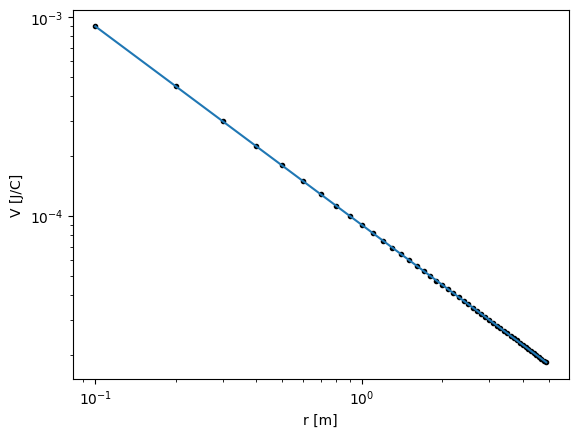

De gevonden waarde voor de exponent is -1 +/- 2e-17.


In [3]:
###
###Hier jouw code###
# 1 op index 50.
z0 = np.argmin(abs(z))
print('Het index is %d.' % z0)
#2-4:

def V_r(x,a,n):
    return a*x**n

val1a,cov1a = curve_fit(V_r,r[1:],V[z0,1:])

n_err = np.sqrt(np.diag(cov1a))[1]
exp_n = val1a[1]
plt.figure()
plt.loglog()
plt.plot(r,V[z0],'k.')
plt.plot(r,V_r(r,*val1a))
plt.xlabel('r [m]')
plt.ylabel('V [J/C]')
plt.show()

print("De gevonden waarde voor de exponent is %d +/- %.0e." % (val1a[1],n_err))
###

##### Vraag 1b Het elektrische veld rond een puntlading
1. Voer van vraag 1a 2 tot 4 uit voor het elektrische veld.

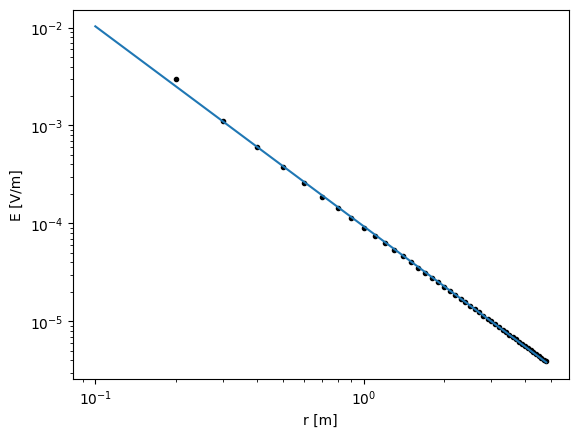

De gevonden waarde voor de exponent is -2.040 ± 0.006.


In [4]:
###
###Hier jouw code###

def log_E_r(x,a,b):
    return a*np.log10(x)+b

val1b,cov1b = curve_fit(log_E_r,r_for_E[1:],np.log10(Er[49,1:]))
a,b = val1b
err_a_1b = np.sqrt(np.diag(cov1b))[0]
plt.figure()
plt.loglog()
plt.plot(r_for_E,Er[49,:],'k.')
plt.plot(r_for_E,10**b*r_for_E**a)
plt.xlabel('r [m]')
plt.ylabel('E [V/m]')
plt.show()

print("De gevonden waarde voor de exponent is %.3f \u00B1 %.3f." % (a,err_a_1b))
###

### 2) Een uniform geladen schijf bestaande uit puntladingen

In de code hieronder wordt een geladen schijf gemaakt via het superpositie principe. Dit wordt gedaan door een rooster van punten in de ruimte te creëren, alle punten die voldoen aan $z = 0$ m en $r < R$ krijgen een lading charge_one_point en vanuit hier wordt het potentiaal bepaald. Hier is de $z$-as de as van de schijf en de r as de afstand tot de $z$-as.



In [5]:
# In vraag 2.1 wordt naar deze cel verwezen. 
disk_radius = 3  # (m)
grid_step = 0.1  # (m)
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

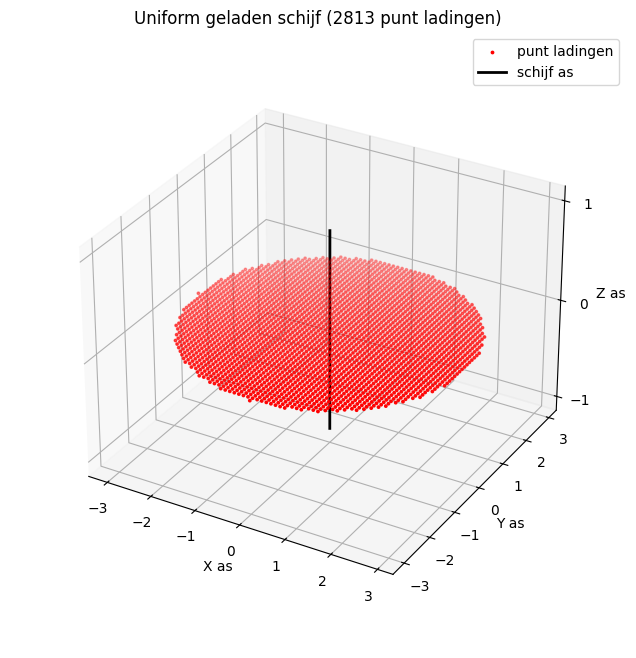

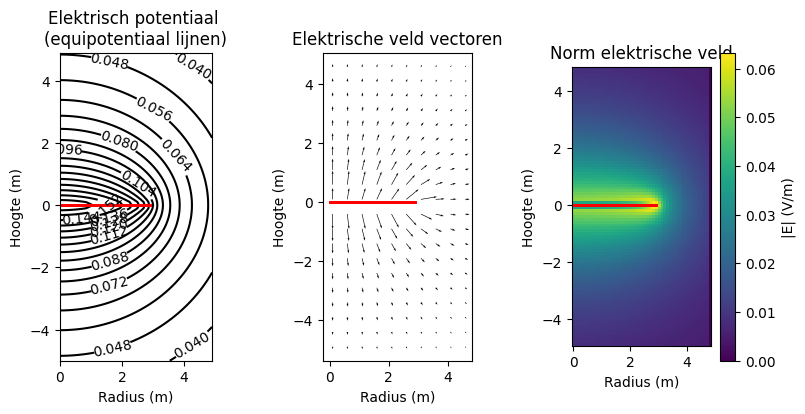

In [6]:
# Kies uit deze cel een van de variabelen en verander die in de cel hierboven pas deze cel zelf niet aan.
r, z, B = initialize_plane_grid_for_uniformly_charged_disk(height_domain, width_domain, grid_step)

idx_z_zero = np.where(abs(z) < 1e-10)[0]
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

V, number_point_charges_on_disk = calculate_V_disk_at_origin_uniform_surface_charge_density(z_coord_DISK, charge_one_point, disk_radius, inter_charge_distance, r, z)
Er, Ez, normE = compute_E_disk(V, B, grid_step)  # gebruik de centered finite-difference method

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_coord_DISK, z_coord_DISK)


#### Vraag 2a

In deze vraag gaan jullie achterhalen wat de variabelen die aan het begin van opgave 2 worden geïnitialiseerd betekenen voor de nauwkeurigheid en snelheid van de code.
Pas voor deze vraag de code die net onder het kopje vraag 2 staat aan. Run dan die cel en de cel daaronder opnieuw om het resultaat van je aanpassing te zien.
1. Wat betekent de disk radius variabele die in de bovenste cel geïnitialiseerd wordt, wat gebeurt er als disk radius naar 0 gaat?
2. Wat betekent gridstep en wat voor impact heeft deze variabele op de simulatie?
3. Pak uit de tweede code cel in opdracht 2 een andere variabelen en onderzoek wat deze variabele doet en wat voor impact die heeft op de simulatie.

##### Antwoorden 2a

1. Het is de afstand tot de z-as waarop puntladingen zitten (oftewel de straal van de disk). Zodra de disk radius naar nul gaat zijn er geen puntladingen meer.
2. De gridstep is de afstand tussen elk deeltje in de x- en y-richting, dus hoe kleiner de gridstep, hoe meer deeltjes er in de schijf passen.
3. De z_coord_disk geeft de z-coordinaat aan van de schijf, maar niet in de 3-D simulatie, alleen in de grafieken eronder.

#### Vraag 2b Oppervlakte lading

Pas de cel die je in vraag 2a hebt aangepast weer aan naar de originele waardes. Run hierna alle code cellen na vraag 2 weer opnieuw.
Het aantal punten dat gebruikt wordt om de schijf te creëren is number_point_charges_on_disk en de lading van een punt is charge_one_point in Coulomb.
1. Bereken en print de ladingsdichtheid $\sigma$ met een correcte eenheid.

In [7]:
###
###Hier jouw code###
sigma = (number_point_charges_on_disk*charge_one_point)/(np.pi*disk_radius**2)

print("De ladingsdichtheid van de schijf is %.3e C/m^2" % sigma)
###

De ladingsdichtheid van de schijf is 9.949e-13 C/m^2


##### Vraag 2c

1. Plot het elektrische potentiaal langs de $r$ as ($z = 0$ m).
2. Plot het potentiaal op de rand van de schijf in hetzelfde figuur $V = \sigma R/(\pi \epsilon_0)$
(bekijk probleem 2.51 in het Griffiths' boek)
3. Plot het potentiaal in het centrum van de schijf in hetzelfde figuur $V = \sigma R/(2 \epsilon_0)$

Text(0.5, 0, 'r [m]')

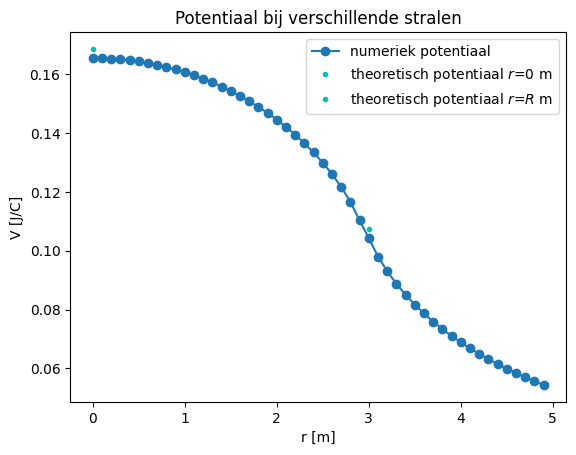

In [8]:
# Vul deze code aan zodat deze vraag 2.3 beantwoord.
idx_z_zero = np.argmin(abs(z))

V_0 = sigma*disk_radius/(epsilon0*2) # potentiaal op r = 0

V_R =  sigma*disk_radius/(epsilon0*np.pi) # potentiaal op de straal van de schijf
r_R =  disk_radius # straal van de schijf

plt.title(f"Potentiaal bij verschillende stralen")
plt.plot(r, V[idx_z_zero,:], "o-", label="numeriek potentiaal")
plt.plot(0, V_0, "c.", label="theoretisch potentiaal $r$=0 m")
plt.plot(r_R, V_R, "c.", label="theoretisch potentiaal $r$=$R$ m")
plt.legend()
plt.ylabel("V [J/C]")
plt.xlabel("r [m]")



#### Vraag 2d

Het theoretische potentiaal op de as van een hele grote schijf ($R>>z$) is:
$V(z, r=0) = \frac{\sigma}{2\epsilon_0} \big( R - |z|\big)$
zie probleem 2.26 in het Griffiths boek.
1. Plot het numeriek berekend elektrische potentiaal op de $z$-as ($r=0$).
2. Plot het theoretische component van het potentiaal op de as van een schijf met ladingsdichtheid $\sigma$.
3. Sla deze plot op.


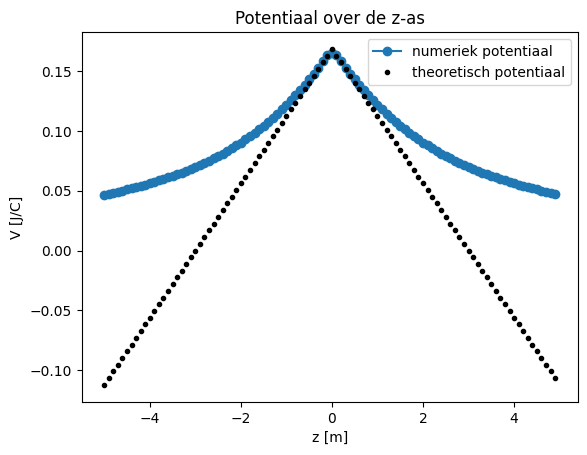

In [9]:
###
###Hier jouw code###
theoretisch_V = sigma*(disk_radius-np.abs(z))/(2*epsilon0)
plt.figure()
plt.plot(z, V[:,0], "o-", label="numeriek potentiaal")
plt.plot(z,theoretisch_V,'k.',label='theoretisch potentiaal')
plt.xlabel('z [m]')
plt.ylabel( 'V [J/C]')
plt.title('Potentiaal over de z-as')
plt.legend()
plt.savefig('2d_potentiaal_z-as.png')
plt.show()
###

#### Vraag 2e

Het theoretische elektrische veld van een oneindig geladen oppervlakte is $|E| = \sigma/(2 \epsilon_0)$ (zie Example 2.5 in het Griffith boek).
1. Plot het z-component van het numeriek berekende elektrische veld op de as van de schijf ($r=0$).
2. Plot het theoretische elektrische veld voor een oneindig geladen oppervlak.
3. Sla deze plot ook op.

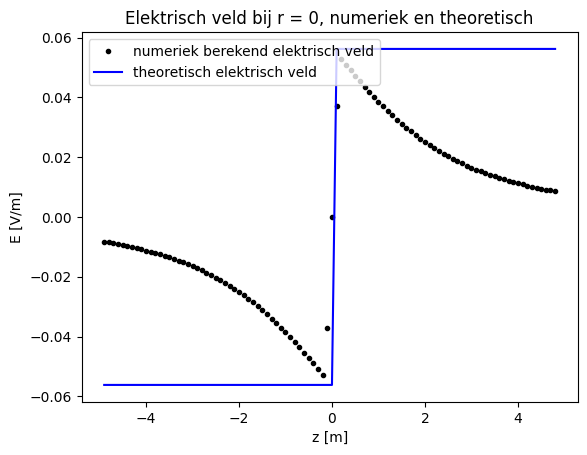

In [10]:
###
###Hier jouw code###
theoretisch_E = sigma/(2*epsilon0)
array_theo_E = theoretisch_E*np.sign(z_for_E) # z-component negatief onder de schijf = negatief, boven schijf = positief.
plt.figure()
plt.plot(z_for_E,Ez[:,0],'k.',label='numeriek berekend elektrisch veld')
plt.plot(z_for_E,array_theo_E,'b-',label='theoretisch elektrisch veld')
plt.xlabel('z [m]')
plt.ylabel('E [V/m]')
plt.legend(loc='upper left')
plt.title('Elektrisch veld bij r = 0, numeriek en theoretisch')
plt.savefig('2e_elektrisch_veld_z-as.png')
plt.show()
###

#### Vraag 2f
1. Waar benadert het elektrische veld van een uniform geladen schijf dat van een oneindig geladen plaat?
2. Beschrijf en verklaar de verschillen die je opvallen in de plot die je bij vraag 2e hebt gemaakt.

##### Antwoorden 2f

1. Hoe dichter je bij z = 0 komt, hoe beter je de oneindig geladen plaat benadert.
2. In theorie is het elektrisch veld van een oneindig geladen plaat constant, doordat de elektrische veldlijnen overal evenwijdig zijn. Onze schijf is echter eindig. Hierdoor neemt, naarmate je van de plaat afgaat het elektrisch veld af. 


#### Vraag 2g

1. Pas helemaal bovenaan in vraag 2 de straal van de schijf aan.
2. Voer dan vragen 2d en 2e opnieuw uit.
3. Voeg de opgeslagen figuren hieronder toe.
4. Beschrijf de verschillen tussen de twee verschillende stralen.

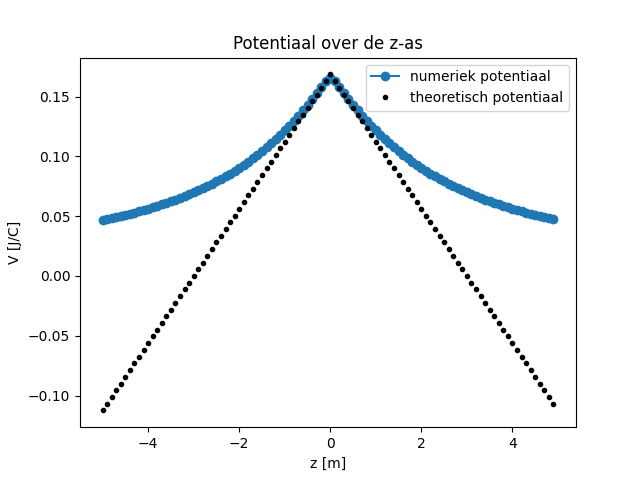

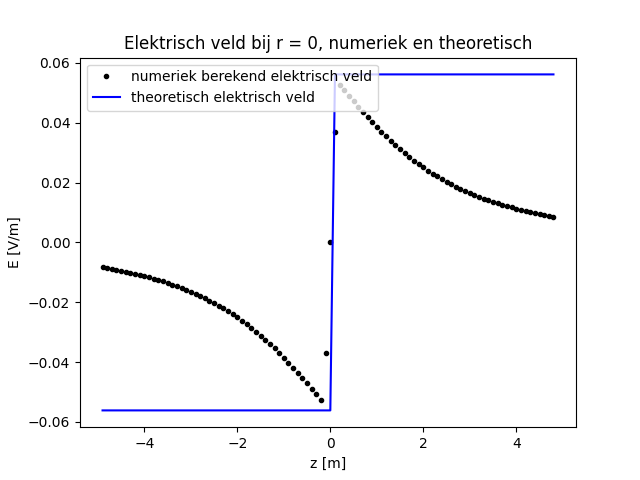

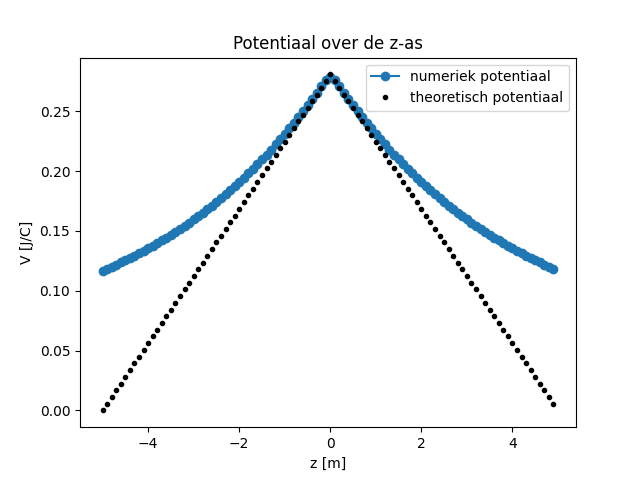

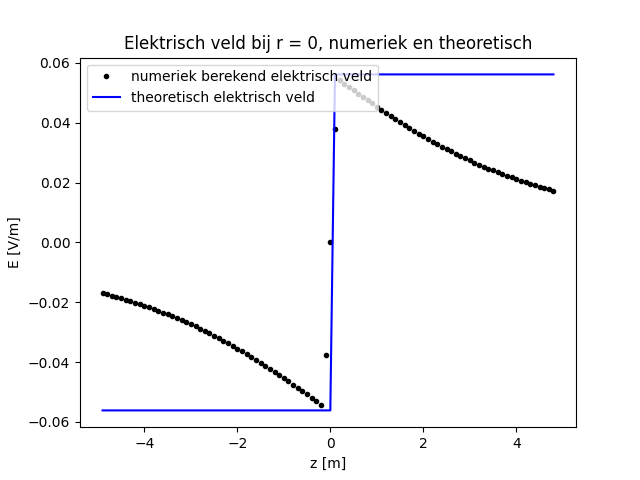

In [11]:
###
###Jouw code hier###
###
display(Image("2d_potentiaal_z-as.png"))
display(Image("2e_elektrisch_veld_z-as.png"))
display(Image("2d_potentiaal_z-as_5m.png"))
display(Image("2e_elektrisch_veld_z-as_5m.png"))


##### Antwoorden 2g

*Edit deze markdown cel met je antwoorden.* \
Hoe groter de straal van de schijf, hoe beter de plaat een oneindig geladen plaat benadert. Dit zie je bij zowel het elektrisch veld als de potentiaal.
Bij de potentiaal zie je ook dat hij hoger is doordat je meer ladingen hebt op de schijf. Bij het elektrisch veld zie je dat hij gelijk blijft, en alleen beter benadert wordt.

#### Vraag 2h
Het elektrische veld een afstand $z$ boven het midden van een uniform geladen schijf met een straal $R$ en oppervlakte lading $\sigma$ wordt gegeven door:
$$ \mathbf{E} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}}$$
Zie probleem 2.6 in het boek van Griffith.

1. Wat moet de hoogte $z$ zijn boven de schijf zodat het elektrische veld door de schijf 10% is in vergelijking met dat van een oneindig geladen plaat?

Voeg hieronder je analytische uitwerking toe.

##### Antwoord 2h

*Edit deze markdown cel met je antwoord.*
Voor de oneindig geladen plaat geldt: $$ \mathbf{E} = \frac{\sigma}{2\epsilon_0} $$

Dus volgt voor 0.1*E: $$0.1 = 1- \frac{z}{\sqrt{R^2 + z^2}}$$
uitwerking: 0.9 = z/(sqrt(z^2+R^2)) \
0.9(sqrt(z^2+R^2)) = z \
z^2 = 0.81(z^2+R^2) \
z^2=0.81(R^2+z^2) \
z^2=0.81R^2+0.81z^2 \
z^2-0.81z^2=0.81R^2 \
0.19z^2=0.81R^2 \
z^2=(0.81/0.19)R^2 
$$z=R\sqrt{\frac{0.81}{0.19}}$$



### 3) Een geladen schijf op een constant potentiaal

We zullen nu het verschil bestuderen tussen een uniform geladen schijf en een geleidende schijf die op een bepaald potentiaal gehouden wordt.
De code hieronder lost numeriek de laplace vergelijking op voor een geleidende schijf op een constant potentiaal. Hieruit volgt het potentiaal in de ruimte.

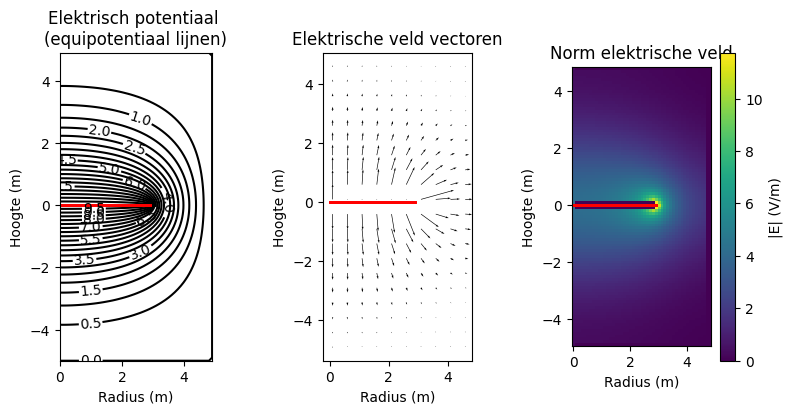

In [12]:
# Run deze cel pas deze niet aan.
V0 = 0  # electric potential at boundary of domain (V)

# Één schijf
z_pos_disk1 = 0  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = z_pos_disk1  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V1)

"""--------------------------------------------------------------------
Veldberekening voor een geleidende schijf
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V1, 1e-3)
Er, Ez, normE = compute_E_disk(V,B,grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)

#### Vraag 3a: De simulatie van het elektrische veld van een geleidende schijf op constant potentiaal

1. Plot de elektrische veld sterkte op de as van de schijf.
2. Print de norm van het elektrische veld op de as heel dicht bij het midden van de schijf, zorg hier voor een nette opmaak.

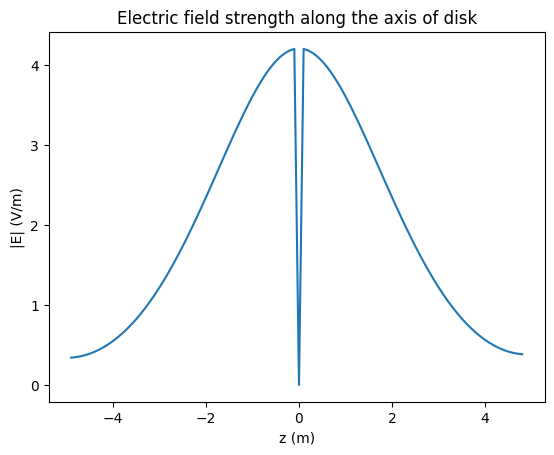

De grootte van het E-veld in het midden van de disk is 1.521e-05 V/m.


In [13]:
#plotting e field strength on the axis
idx_rzero = np.argmin(abs(r_for_E))
plt.figure()
plt.plot(z_for_E,normE[:,idx_rzero])
plt.xlabel('z (m)')
plt.ylabel('|E| (V/m)')
plt.title("Electric field strength along the axis of disk")
plt.show()


#printing norm @ center of disk
z_pos_disk1 = 0
idx_z0 = np.argmin(np.abs(z_for_E))
E_center = normE[idx_z0,0]
print(f"De grootte van het E-veld in het midden van de disk is {E_center:.3e} V/m.")


#### Vraag 3b: De oppervlakte lading in het midden van een geleidende schijf op constant potentiaal

1. Met welke formule kan je de oppervlaktelading benaderen in het midden van de schijf($r=0$, $z=0$)?
2. Print netjes de benadering van de oppervlakte lading in het midden van de schijf.

##### Antwoord 3b

$\sigma(0) \approx \epsilon_{0}E_z(0^+,r=0)$ \
Volgend uit: \
E_loodrecht_boven-E_loodrecht_binnen = sigma/epsilon0 \
E_loodrecht_binnen = 0 \
E_loodrecht_boven = sigma/epsilon0

In [14]:
import numpy as np

Ez_surface = Ez[idx_z0+1,0]#E field just above disk
sigma_center = epsilon0*Ez_surface#surface charge density
print(f'The approximate surface charge density at the center of the disk is {sigma_center:.3e} C/m^2')

The approximate surface charge density at the center of the disk is 3.720e-11 C/m^2


#### Vraag 3c: De oppervlaktelading van een geleidende schijf op constant potentiaal

De oppervlakte lading $\sigma(r)$ van een geleidende schijf met straal $R$ is niet uniform verdeeld over de schijf, maar wordt gegeven door (Problems 2.58 and 2.63 Griffiths 5th edition):
$$\sigma(r) = \frac{Q}{2 \pi R \sqrt{R^2 - r^2}}$$

1. Bereken de totale lading op de schijf met behulp van vraag 3a en 3b.
2. Vergelijk de oppervlakte lading in het centrum van de geleidende schijf met dat van een uniform geladen schijf met dezelfde totale lading.
3. Plot de oppervlakte lading van de geleidende schijf met de berekende lading $Q$, tussen $r = 0$ en $R$.
4. Plot in hetzelfde figuur de oppervlaktelading van een uniform geladen schijf met dezelfde lading $Q$.


De totale charge is 2.1e-09 C.
sigma op het midden van de schijf (geleider): 3.720e-11 C/m^2
sigma uniform: 7.441e-11 C/m^2
ratio sigma bij centrum (geleidende schijf)/sigma_uniform: 0.5


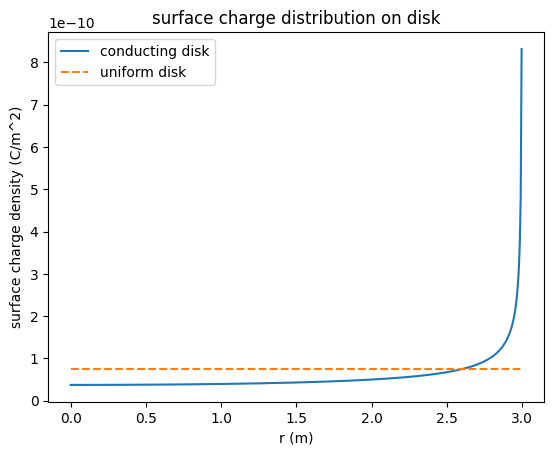

In [15]:
R = disk_radius
Q = 2*np.pi*R**2*sigma_center #compute tot charge
sigma_uniform = Q/(np.pi*R**2) #comparing denity @ center w/ uniform disk chrg density
print('De totale charge is %.1e C.' % Q)
print('sigma op het midden van de schijf (geleider): %.3e C/m^2' %sigma_center)
print('sigma uniform: %.3e C/m^2' %sigma_uniform)
print('ratio sigma bij centrum (geleidende schijf)/sigma_uniform:',sigma_center/sigma_uniform) # Ladingen niet allemaal naar de buitenkant, want anders is het niet meer equipotentiaal, doordat je een E-veld component langs de rand krijgt.

r_val = np.linspace(0,R*0.999,500)# creating array of r values <R since r=!R

sigma_conducting=Q/(2*np.pi*R*np.sqrt(R**2-r_val**2))#calculating density of conducting disk
sigma_uniform_array = np.ones_like(r_val)*sigma_uniform

plt.figure()
plt.plot(r_val, sigma_conducting, label='conducting disk')
plt.plot(r_val, sigma_uniform_array, '--',label='uniform disk')
plt.xlabel('r (m)')
plt.ylabel('surface charge density (C/m^2)')
plt.title('surface charge distribution on disk')
plt.legend()
plt.show()
 

#### Vraag 3d: Het edge effect

1. Bepaal het maximum elektrische veld door de geleidende schijf in de simulatie.
2. Bepaal waar in de ruimte dit maximum zich bevindt.
3. Hoeveel hoger is dit maximum dan het elektrische veld in het midden van de schijf?
4. Print met een nette opmaak de waardes die je hier hebt berekend.
5. Leg uit wat de oorzaak van dit lokaal hoge elektrische veld is?


In [16]:
# Deze cel kan je gebruiken om van vraag 3c 1 tot en met 4 te beantwoorden.
#finding max e field & index
max_E = np.max(normE)
max_idx = np.unravel_index(np.argmax(normE),normE.shape) #giving the z and r indexes
r_max = r_for_E[max_idx[1]] #index for r
z_max = z_for_E[max_idx[0]] #index for z
#comparing to disk cent
edge_to_center_ratio=max_E/E_center
edge_to_center_diff = max_E-E_center
print(f'Max E-field aan de rand: E_max = {max_E:.3e} V/m at r = {r_max:.3f} m, z ={z_max:.3f} m')
print(f'E-field midden van schijf: E_center={E_center:.3e} V/m')
print(f'Het veld aan de rand is {edge_to_center_ratio:.1f} keer sterker dan het veld in het midden van de schijf.')
print(f'Het veld aan de rand verschilt {edge_to_center_diff:e} met het veld in het midden van de schijf.')

Max E-field aan de rand: E_max = 1.175e+01 V/m at r = 3.000 m, z =0.100 m
E-field midden van schijf: E_center=1.521e-05 V/m
Het veld aan de rand is 772488.6 keer sterker dan het veld in het midden van de schijf.
Het veld aan de rand verschilt 1.175298e+01 met het veld in het midden van de schijf.


##### Antwoord 3d.5
Het elektrisch veld aan de uiteinden is hoog omdat de ladingen opeenhopen aan de uiteinden van een geleider omdat ze worden afgestoten door de ladingen, en dit veroorzaakt een hoger e-veld (door de opeenhoping van de ladingen). Door deze opeenhoping is er minder lading in het midden, en dit is het edge-effect. Echter niet alle ladingen bewegen naar de buitenkant, anders zou er een paralelle component aan het elektrisch veld en het geen equipotentiaal zijn (en dus geen geleider zijn). Ook uit de formule volgt dat naarmate je dichter bij de rand van de schijf komt, je ladingsdichtheid, en dus de loodrechte component van het elektrisch veld, naar oneindig gaat.

### 4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$

In de cel hieronder wordt weer op dezelfde manier als in opdracht 3 de laplace vergelijking van deze situatie opgelost.

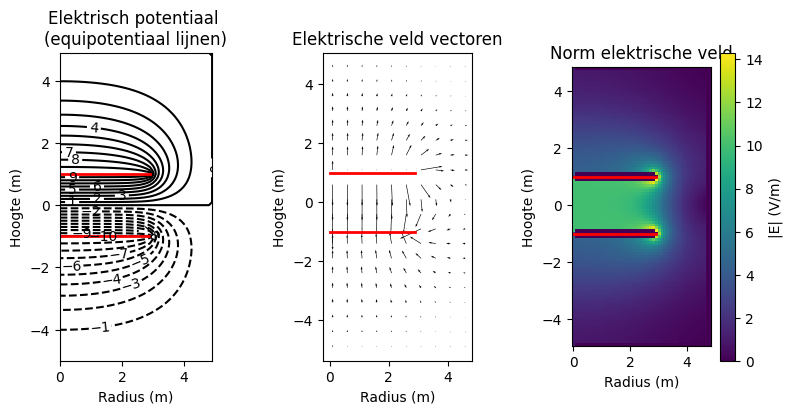

In [17]:
# Run deze cel en pas de cel aan in vraag 4f.
# Voor twee schijven
spacing_between_disks = 2  # (m)
z_pos_disk1 = spacing_between_disks/2  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = -spacing_between_disks/2  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)
V2 = -10  # elektrische potentiaal van de tweede geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V2)

"""--------------------------------------------------------------------
Veldberekening voor de twee geleidende schijven
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V2, 1e-3)
Er, Ez, normE = compute_E_disk(V, B, grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)


#### Vraag 4a: Het $z$-component van het numeriek berekende elektrische veld van twee geleidende platen

1. Plot het $z$-component van het numeriek berekende elektrische veld op de as van de schijven.


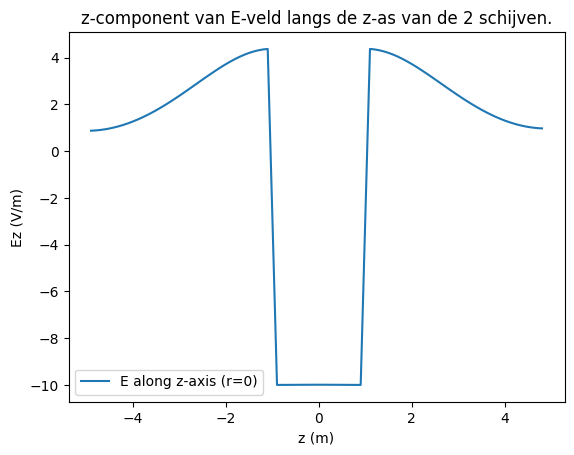

In [18]:
Ez_axis = Ez[:,0] # Ez op de z-as, met index 0 (waar r 0 is).
z_axis = z_for_E 
plt.figure()
plt.plot(z_axis,Ez_axis, label='E along z-axis (r=0)')
plt.xlabel('z (m)')
plt.ylabel('Ez (V/m)')
plt.title('z-component van E-veld langs de z-as van de 2 schijven.')
plt.legend()
plt.show()

#### Vraag 4b: Verschillen tussen verschillende configuraties

1. Gegeven het potentiaal tussen twee geleidende platen, wat is het theoretische elektrische veld in elke regio? Laat dit zien met een afleiding en een schets die de verschillende regio's aangeeft.
2. Beschrijf het numeriek berekende elektrische veld op de as van de schijven, komt dit overeen met het theoretische elektrische veld?
3. Vergelijk het numeriek berekende elektrische veld tussen de twee schijven ($r=0$ and $z=0$) met dat van een enkele geleidende schijf op hetzelfde potentiaal(vraag 3a), welk voordeel heeft deze configuratie?

1) $E_z = -\frac{dV}{dz} = \frac{V_1-V_2}{d} = \frac{10-(-10)}{2}= 10V/m$ \
Het elektrisch veld tussen de platen is constant, buiten de platen is het veld 0, beiden kanten heffen elkaar precies op, en binnen de platen is het veld ook 0, omdat het veld binnen geleiders over het algemeen 0 is.

2) Ez is zo goed als contant en er is een kleine verbuiging aan de uiteinden van de schijven door "edge effects", in de schijven is Ez 0 doordat het veld in een geleider 0 is. Buiten neemt het veld af. Dit komt overeen met de theorie door het afvallen, maar de randeffecten worden verwaarloosd. Dit komt dus niet overeen met de theorie.

3) Het veld wordt groter bij een 2 disk setup. Voordelen hiervan zijn dat er een uniformer veld is en een betere controle van de veldlijnen. Ook is het veld bij één schijf zwakker.

![figure 4b](figures/IMG_6565.jpeg)

#### Vraag 4c: De capaciteit tussen twee geleidende platen

1. Bepaal de verwachte oppervlakte lading op de binnenzijde van een van de schijven.
2. Bepaal de verwachte totale lading op beide schijven.
3. Bepaal de capaciteit van deze situatie.
4. Print alle bepaalde waardes op een nette en overzichtelijke manier.

In [19]:
### In vraag 1 is gezegd dat we een oppervlakte lading moeten geven. Ik neem aan dat ze hiermee de ladingsdichtheid bedoelen op het oppervlak.
###your code here###
###
# 4 zit door alle 3 heen.

# 1.

E_binnenzijde = (V1-V2)/2 # op 1 schijf
sigma_verwacht = epsilon0*E_binnenzijde
Q_verwacht = sigma_verwacht*np.pi*R**2
print(f'Charge density 1 disk: {sigma_verwacht:.3e} C')

# 2. 

print(f'tot charge on 2 disks {Q_verwacht:.3e} C')

# 3.
C = Q_verwacht/(V1-V2)
print(f'cap van systeem {C:.3e} F')





Charge density 1 disk: 8.854e-11 C
tot charge on 2 disks 2.503e-09 C
cap van systeem 1.252e-10 F


#### Vraag 4d: Theoretische oppervlakte lading

1. Is de oppervlaktelading aan de buitenkant van de schijven gelijk aan nul, beargumenteer waarom wel of niet.
2. Wat is het elektrische veld nabij het oppervlak van een geleider?

1) De buitenoppervlakken dragen geen lading. Dit komt doordat de randvelden aan de oppervlakten het E-veld precies opheffen. De buitenoppervlakken zijn 'afgeschermd' en hebben geen lading nodig, omdat ze niet bijdragen aan het potentiaalverschil tussen de schijven. Ook is het veld tussen de schijven uiteindelijk neutraal; de +-ladingen heffen de negatieve ladingen precies op.
2) Het veld dichtbij het oppervlak van een geleider staat loodrecht op het oppervlak zelf en de grootte ervan is evenredig met de lokale ladingsdichtheid aan het oppervlak: hoog nabij de randen en laag in het midden. $E_{loodrecht} = \frac{\sigma}{\epsilon_0}$ , volgend uit de randvoorwaardes van een geleider.

#### Vraag 4e: Numeriek berekende ladingsdichtheid

1. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net onder de onderste schijf.
2. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de onderkant van de onderste geleidende plaat.
3. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net boven de onderste schijf.
4. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de bovenkant van de onderste geleidende plaat.
5. Print de bepaalde waardes op een nette en overzichtelijke manier.

In [20]:
###
###Your code here###
###
idx_disk2 = np.argmin(np.abs(z_for_E-z_pos_disk2))
Ez_below = Ez[idx_disk2-1,0]# E waar r 0 is onder de schijf
Ez_above = Ez[idx_disk2+1,0]# E waar r 0 is boven de schijf
sigma_bottom = epsilon0*Ez_below
sigma_top=epsilon0*Ez_above 
print('lower disk (z={:.2f}m)surface charge densities'.format(z_for_E[idx_disk2]))
print(f'Ez just below bottom surface {Ez_below:.3e} V/m, sigma_bottom = {sigma_bottom:.3e} C/m^2')
print(f'Ez just above top surface {Ez_above:.3e} V/m, sigma_top = {sigma_top:.3e} C/m^2')

lower disk (z=-1.00m)surface charge densities
Ez just below bottom surface 4.377e+00 V/m, sigma_bottom = 3.875e-11 C/m^2
Ez just above top surface -1.000e+01 V/m, sigma_top = -8.858e-11 C/m^2


#### Vraag 4f: Conclusies over de ladingsdichtheid op de twee schijven

1. Wat kan je uit vraag 4d en e concluderen over de daadwerkelijke lading op een schijf in tegenstelling tot de berekende lading in vraag 4c?
2. Wat is de invloed hiervan op de capaciteit berekend in vraag 4c?
3. Run de cel net onder het kopje vraag 4 opnieuw, maar dan met een kleinere afstand tussen de schijven, wat verandert er?

##### Antwoorden 4f

# 1.

- De ladingsdichtheid op de bovenkant en onderkant van de onderste schijf is niet gelijk.
- De ladingsdichtheid op de buitenzijde is niet exact nul.
- De ladingsdichtheid is niet uniform over het oppervlak (rand-effecten).



# 2.


De eindige afmetingen van de schijven en randvelden verlagen de capaciteit in vergelijking met de theorie, doordat de totale lading minder is.


# 3.
Naarmate de afstand tussen de schijven kleiner wordt, nemen de interne ladingsdichtheid, de totale lading op de schijf en de sim-capaciteit toe, wat aantoont dat dichtere schijven leiden tot een hogere capaciteit.

### 5) Voorbereidende opdracht voor de fysieke DEF ontwerpopdracht

In deze vraag zullen we ingaan op benodigde voorkennis voor de fysieke ontwerpopdracht "Maak een sensor met condensatoren". De formules die je in deze opdracht opstelt, heb je nodig gedurende de fysieke ontwerpopdracht.

In deze vraag zullen we kijken naar de ideale vlakke plaat condensator. Als de afstand tussen de platen veel kleiner is dan de grootte van de platen dan wordt de aanname gemaakt dat het veld tussen de platen constant is. Deze aanname zal niet helemaal overeenkomen met de werkelijkheid, zoals je in deze opdracht en de fysieke DEF ontwerpopdracht achter zal komen.

#### Vraag 5a: Functies voor de capaciteit van enkele opdrachten

1. Vind de formule voor de capaciteit van een vlakke plaat condensator en een cilinder condensator, onder de aanname dat de afstand tussen de platen veel kleiner is dan het oppervlakte van de condensator (vlakke plaat aanname).
E = sigma/e0, sigma = Q/A, V = Ed -> C = Q/V = Ae0/d
2. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een vlakke plaat condensator als output heeft.
3. Vind de formule voor de capaciteit van een cilinder condensator onder de aanname dat de afstand tussen de binnen en buiten wand klein is.
C = 2pi*epsilon0epsilonr*L/ln(b/a)
4. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een cilinder condensator als output heeft.

In [21]:
def vlakkeplaat(epsilon,A,d):
    C = epsilon*A/d
    return C

def cilinder(epsilon,L,r_buiten,r_binnen):
    C = 2*np.pi*epsilon*L/np.log(r_buiten/r_binnen)
    return  C

#### Vraag 5b: Capaciteit van enkele simpele condensatoren

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder staan een aantal condensatoren waarvoor jullie de capaciteit gaan berekenen. Print de capaciteit van elke condensator op een nette en overzichtelijke manier.
1. Bereken de capaciteit van een condensator gemaakt van twee vierkante plaatjes van 10 bij 10 cm met een plaatafstand van 1 mm en lucht als medium?
2. Bereken de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm met een lengte van 10 cm en lucht als medium?
3. Bereken de capaciteit van de condensatoren als de afstand tussen de platen verdubbeld
4. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven beschreven als ze gevuld zijn met water.
5. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven als de holte gevuld is met PVC.


In [22]:
###
###your code here###
###
# 1. 
A1 = 0.1*0.1 # m
d1 = 1e-3 # m
c_1 = vlakkeplaat(epsilon0,A1,d1) # F
print('De capaciteit van de platen bij 1 is %.3e F.' % c_1)
# 2.
r_in1 = 4.5e-3 # m
r_out1 = 5e-3 # m
len = 10e-2 # m
c_2 = cilinder(epsilon0,len,r_out1,r_in1) # F
print('De capaciteit van de cilinder bij 2 is %.3e F.' % c_2)
# 3.1
d3 = d1*2
c3_1 = vlakkeplaat(epsilon0,A1,d3) # F
print('De capaciteit 3 van de vlakke plaat is %.3e F.' % c3_1) # vlakke plaat
# 3.2
r_in2 = 4e-3 # m
r_out2 = 6e-3 # m
c3_2 = cilinder(epsilon0,len,r_out2,r_in2) # F
print('De capaciteit bij 3 van de cilinder is %.3e F.' % c3_2) # cilinder
# 4.1
epsilonw = 80*epsilon0 
c4_1 = vlakkeplaat(epsilonw,A1,d1)
print('De capaciteit bij 4 van de vlakke plaat is %.3e F.' % c4_1)
# 4.2
c4_2 = cilinder(epsilonw,len,r_out1,r_in1)
print('De capaciteit bij 4 van de cilinder is %.3e F.' % c4_2)
# 5.1
epsilon_pvc = 4.5*epsilon0
c5_1 = vlakkeplaat(epsilon_pvc,A1,d1)
print('De capaciteit bij 5 van de vlakke plaat is %.3e F.' % c5_1)
# 5.2
c5_2 = cilinder(epsilon_pvc,len,r_out1,r_in1)
print('De capaciteit bij 5 van de cilinder is %.3e F.' % c5_2)

De capaciteit van de platen bij 1 is 8.854e-11 F.
De capaciteit van de cilinder bij 2 is 5.280e-11 F.
De capaciteit 3 van de vlakke plaat is 4.427e-11 F.
De capaciteit bij 3 van de cilinder is 1.372e-11 F.
De capaciteit bij 4 van de vlakke plaat is 7.083e-09 F.
De capaciteit bij 4 van de cilinder is 4.224e-09 F.
De capaciteit bij 5 van de vlakke plaat is 3.984e-10 F.
De capaciteit bij 5 van de cilinder is 2.376e-10 F.


#### Vraag 5c: Condensatoren uit het dagelijkse leven

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder is een foto te zien van condensatoren die in het dagelijkse leven gebruikt wordt.
Print de capaciteiten in deze vraag op een nette en overzichtelijke manier.
1. In figuur 5.1 is een condensator te zien van 1 $\micro$F, stel deze condensator kan geapproximeerd worden als een cilinder condensator met binnendiameter 5 mm en een buitendiameter van 6 mm. Bereken wat de lengte van de condensator dan zou zijn.
Stel dat we een vierkante plaat condensator hebben van 1 $\micro$F.
2. Bereken hoe lang de vlakke plaat condensator moet zijn als er 0.5 mm tussen de platen zit en de platen 6 mm breed zijn.

![figure 5.1](figures/Condensator_1_uF.jpg)

##### Figure: 5.1 Een 1 microfarad condensator.

In [23]:
###
###Jouw code hier### Omschrijven van de formule bij vraag 5a geeft:
C_condensator = 1e-6 # F
# 1a 
r_binnen = 5e-3/2 # m
r_buiten = 6e-3/2 # m
len_5d1 = C_condensator*np.log(r_buiten/r_binnen)/(2*np.pi*epsilon0)
print('De lengte van de cilinders zijn %d m.' % len_5d1)
# 1b
d_platen = 0.5e-3 # m
b_platen = 6e-3 # m
len_5d2 = C_condensator*d_platen/(epsilon0*b_platen)
print('De lengte van de platen zijn %d m.' % len_5d2)

De lengte van de cilinders zijn 3277 m.
De lengte van de platen zijn 9411 m.


#### Vraag 5d: Hoge capaciteit condensatoren

1. Beargumenteer of je antwoorden uit vraag 5c realistisch zijn.
2. Bekijk je formule uit vraag 5a en bedenk hoe ze dit binnen in de condensator opgelost hebben.

##### Antwoorden 5d

*Beantwoord hier de vraag 5d.*
1. Ze zijn niet realistisch. 
2. De stof tussen de cilinders moet een hoge permittiviteit hebben, of de afstand tussen de platen moet heel erg klein zijn.

#### Vraag 5e: Condensator in een achtbaan

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

Met het vak inleidend practicum zijn jullie naar Drievliet gegaan om daar metingen aan de attracties te doen. In Drievliet staat de achtbaan Formule X, deze achtbaan heeft een topsnelheid van 70 $\frac{\text{km}}{\text{h}}$ en bevat een treintje met plek voor 6 mensen. Deze snelheid bereikt de achtbaan door heel snel een karretje weg te schieten, dit wordt gedaan door de treintjes met een lineaire inductie motor te versnellen. Om de impact hiervan op het stroomnet te beperken gebruiken zij een condensator om de energie op te slaan en dan in een keer af te staan aan het treintje. In deze opdracht gaan we kijken wat de afmetingen zouden moeten zijn als ze vlakke plaat condensatoren zouden gebruiken.

De energie die opgeslagen is in een condensator kan berekend worden met de onderstaande formule.

$E = \frac{1}{2} CV^2$
Hierin is $E$ de totaal opgeslagen energie $C$ de capaciteit en $V$ het voltage waarop de condensator opereert, in dit geval $10$ $kV$.
1. Schat de massa van een treintje dat afgeschoten wordt.
2. Bereken de totale energie van het treintje na het afschieten.
3. Bereken de totale capaciteit van de condensator.
4. Bereken het oppervlakte van een vlakke plaat condensator die deze capaciteit heeft als die gevuld is met water en de platen 1 mm van elkaar afstaan.
5. Print alle berekende waardes op een nette en overzichtelijke manier.
6. Is dit realistisch, bedenk een manier hoe dit toch kan in een relatief klein volume.


In [24]:
###
###Jouw code hier###
# 1.
m_kar = 2000 # kg
v = 70/3.6 # m/s
V = 10**4 # V
# 2. 
E_kin = 0.5*m_kar*v**2
print("De kinetische energie van de kar na het afschieten is %.3e J."  % E_kin)
# 3.
C_kar = 2*E_kin/(V**2) 
print("De capaciteit van de kar na het afschieten is %.3f F." % C_kar)
# 4. 
distance_platen = 1e-3
A_vlakkeplaat = C_kar*distance_platen/epsilonw
print("De oppervlakte van de condensator  is %.3e m^2." % A_vlakkeplaat)
###

De kinetische energie van de kar na het afschieten is 3.781e+05 J.
De capaciteit van de kar na het afschieten is 0.008 F.
De oppervlakte van de condensator  is 1.068e+04 m^2.


##### Antwoorden 5e

6. Dit is niet realistisch. Hoe dit toch kan met een klein volume is de binnenkant van de condensator plooien (voor een groter oppervlak), of een stof met een andere permittiviteit gebruiken.

#### Vraag 5f: Veranderende capaciteit

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

1. Bereken en plot de capaciteit van een vlakke plaat condensator van $10$ bij $10$ $cm$ waarbij de afstand tussen de platen lineair toeneemt van $0.5$ $mm$ tot $5$ $mm$.
2. Bereken en plot de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm en 10 cm lang, waarbij de binnencilinder er langzaam in 10 seconde uitgetrokken wordt.

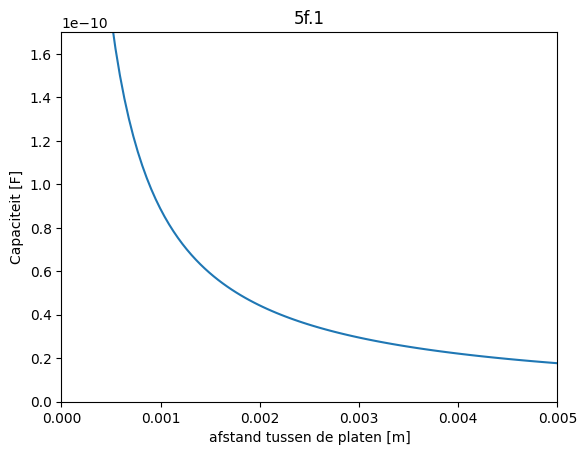

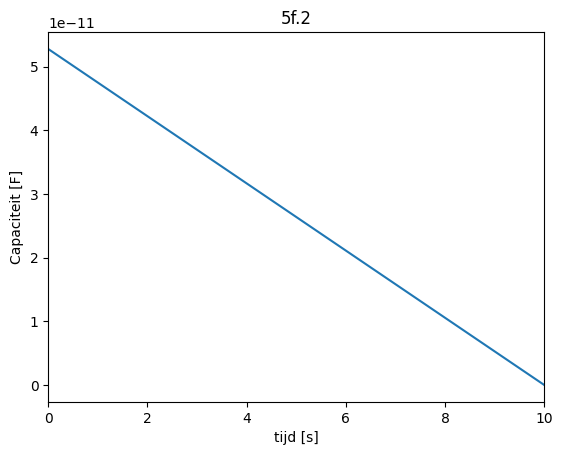

In [25]:
###
###Jouw code hier###
# 1. 
A_5f = 0.1*0.1 # m
d_5f = np.linspace(0.0005,0.005,101)
C_5f1 = epsilon0*A_5f/d_5f
plt.figure()
plt.plot(d_5f,C_5f1)
plt.xlabel('afstand tussen de platen [m]')
plt.ylabel('Capaciteit [F]')
plt.xlim(0,0.005)
plt.ylim(0,1.7e-10)
plt.title('5f.1')
plt.show()

# 2.
r_5f_bin = 4.5e-3
r_5f_uit = 5e-3
l_5f = np.linspace(0.1,0,10)
C_5f2 = 2*np.pi*epsilon0*l_5f/(np.log(r_5f_uit/r_5f_bin))
tijd = np.linspace(0,10,10)
plt.figure()
plt.plot(tijd,C_5f2)
plt.xlabel('tijd [s]')
plt.ylabel('Capaciteit [F]')
plt.xlim(0,10)
plt.title('5f.2')
plt.show()
###

## Stop hier met werken tot na de fysieke ontwerpopdracht in week 3.

### 6) Reflectie opdracht voor na de fysieke ontwerpopdracht


Als het goed is, heeft ieder teamlid van deze simulatie-opdracht een andere opstelling ontworpen hebben tijdens de fysieke ontwerpopdracht. Kies in goed overleg voor deze opdracht een van jullie twee ontwerpen.

Voeg hieronder eerst een foto in van je opstelling die je gekozen hebt.

Jullie gaan in deze opdracht het verschil tussen jullie voorspelde verband en jullie uiteindelijke verkregen kalibratie grafiek proberen te verklaren. Er zijn hiervoor drie mogelijke paden die jullie kunnen kiezen om te onderzoeken, Kies deel a, b of c en werk die volledig uit voor jullie ontwerp. Let op je hoeft er maar een uit te werken.

Verander de tekst hieronder zodat deze naar jouw foto verwijst. Zorg dat de foto in de map figures staat!
![fig](figures/Opstelling.jpeg)

#### Vraag 6a: Dunne laag niet meegerekende diëlektricum
Deze vraag is goed om te kiezen als je in je ontwerp een kleine laag extra materiaal hebt en deze tijdens de ontwerpopdracht niet hebben meegenomen in je theoretisch kalibratie grafiek.

1. Maak een nieuwe schets van je opstelling waarbij je de dikte van het extra diëlektricum meeneemt.
2. Leid de analytische oplossing af van de capaciteit van de hierboven getekende situatie.
3. Programmeer de analytische oplossing in python.
4. Maak hierna een plot van het kalibratiegrafiek, oude en nieuwe analytische oplossing in een grafiek.
5. Beschrijf en verklaar de verschillen tussen de grafieken.


##### Antwoorden 6a

*Laat in deze cel je analytische oplossing met schets zien, dit mag met foto's of via LATEX.*

In [26]:
# Schrijf hier de code voor je oplossing. Gebruik hier je eerder gemaakte functies
# def condensator_extra_laag(#jouw variabelen): # Schrijf hier jouw functie
    ## je functie


### Maak hier je plot

##### Antwoorden 6a

*Beschrijf en verklaar je verschillen in deze markdown cel.*

#### Vraag 6b1: Lading op een condensator met het edge effect meegenomen

In deze opdracht gaan we verder in op het Edge effect en de invloed daarvan op de praktische capaciteit. Deze opdracht bouwt voort op de vraag 4.3.
Jullie hebben tijdens de ontwerpopdracht vierkante platen gebruikt in tegenstelling tot de ronde platen waarvoor de factoren in figure[label] zijn afgeleid. Er is onderzoek gedaan naar de factoren waarmee de praktische capaciteit vergeleken met de daadwerkelijke capaciteit verschilt dat onderzoek vind je hier: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=311759. Zoek in het onderzoek tabel 1 en formules 22 en 36 op.

1. Vergelijk de factor waarmee de schijf(disk) condensator verschilt met die van de vierkante plaat, kunnen we de vierkante plaat factor benaderen met de factor voor een disk condensator? Vergelijk het procentuele verschil tussen de factoren van de circulaire en vierkante platen, met de onzekerheden die in de meting zitten.



##### Antwoord 6b1
(C_DN-C_SN)/C_SN * 100 = %verschil
De onzekerheid in onze meting is 2%, en onze b-factor is 0.01, en het procentuele verschil bij 0.1 is 1.4%, en er is te zien dat hoe kleiner de aspect ratio, hoe beter de benadering. Bij een aspect ratio van 0.01 is het dus een goede benadering.

| b    | Disk (C_{DN}) | Square (C_{SN}) | % verschil |
| ---- | ------------- | --------------- | ---------- |
| 0.1  | 1.31809       | 1.29980         | **1.4 %**  |
| 0.2  | 1.58007       | 1.54987         | **1.9 %**  |
| 0.3  | 1.83007       | 1.78426         | **2.6 %**  |
| 0.5  | 2.31845       | 2.23581         | **3.7 %**  |
| 0.7  | 2.80352       | 2.67950         | **4.6 %**  |
| 1.0  | 3.53479       | 3.34336         | **5.7 %**  |
| 2.0  | 6.01398       | 5.58217         | **7.7 %**  |
| 3.0  | 8.52857       | 7.85246         | **8.6 %**  |
| 5.0  | 13.59268      | 12.42957        | **9.4 %**  |
| 7.0  | 18.67215      | 17.02431        | **9.7 %**  |
| 10.0 | 26.30143      | 23.92769        | **9.9 %**  |




#### Vraag 6b2: Capaciteit van een condensator met het edge effect meegenomen

Vanaf hier nemen we aan dat factor van de circulaire platen ongeveer gelijk is aan de factor voor vierkante platen. De factor die de capaciteit van de vlakke plaat approximatie linkt aan de werkelijke capaciteit noemen we vanaf nu de idealiteitsfactor.

1. Bereken de daadwerkelijke theoretische capaciteit van de condensator uit de sanity check 3 van de fysieke ontwerpopdracht en print deze op een nette manier.
2. Vergelijk dit met de daadwerkelijke theoretische capaciteit met de capaciteit die je op de dag zelf hebt gemeten.

Vanaf hier gaan we verder met jullie sensor van de ontwerpopdracht "Maak een sensor met condensatoren":

3. Reken je theoretische kalibratie grafiek om met de idealiteitsfactor.
4. Vergelijk je nieuwe theoretische kalibratiegrafiek van je praktische kalibratiegrafiek van de dag zelf.

In [27]:
# Schrijf hier jouw code die de vlakke plaat capaciteit omschrijft naar de werkelijke capaciteit
import numpy as np
epsilon0 = 8.854e-12

def C_niet_ideaal(epsilonr,A,d):
    C = (epsilon0 * epsilonr * A) / d     # Afstand tussen de twee platen << oppervlakte A platen. 
    return C

# 1. Onze aspect ratio is 0.001/0.1 = 0.01. Ik neem de eerste waarde uit tabel 1, bij een aspect ratio van 0.1, om deze te benaderen.
# Uit formule 36: C_DN (de idealiteitsfactor) = C_D(daadwerkelijke meting)/C_D0 (theoretisch, niet ideaal), aflezen uit Tabel 1: C_DN = 1.31809
A = 0.01   # (m^2) oppervlakte platen
d = 0.001   # (m) afstand tussen de platen
epsilonr_karton = 2   # (F/m) permittiviteit van karton (stof tussen de platen)

C_verwacht = C_niet_ideaal(epsilonr_karton,A,d) / 1e-12  # (pF)

print(f"De niet ideale theoretische capaciteit van de  plaatcondensator is {C_verwacht:.1f} pF")



# Met osciloscoop berekend:
A_uit = 750e-3 # (V) amplitude van V_uit
A_in = 8    # (V)
f = 100e3   # (Hz) frequentie
R_sh = 1e3  # (Ohm) weerstand shunt
C_meting = A_uit / (2*np.pi*f*R_sh*A_in * 1e-12)    # (pF)
print(f"De gemeten capaciteit van de plaatcondensator is {C_meting:.1f} pF")
idealiteitsfactor = 1.31809
C_verwacht_werkelijk = idealiteitsfactor*C_verwacht


print(f"De daadwerkelijk theoretische capaciteit van de plaatcondensator is {C_verwacht_werkelijk:.1f} pF")
# 2.
vergelijking = C_meting/C_verwacht_werkelijk*100

print('De gemeten capaciteit van de ontwerpdag zelf was %.1f procent van de daadwerkelijk theoretische capaciteit.' % (vergelijking))


De niet ideale theoretische capaciteit van de  plaatcondensator is 177.1 pF
De gemeten capaciteit van de plaatcondensator is 149.2 pF
De daadwerkelijk theoretische capaciteit van de plaatcondensator is 233.4 pF
De gemeten capaciteit van de ontwerpdag zelf was 63.9 procent van de daadwerkelijk theoretische capaciteit.


##### Antwoorden 6b2

*Doe in deze markdown cel je vergelijkingen voor de sanity check condensator en je kalibratiegrafiek.*

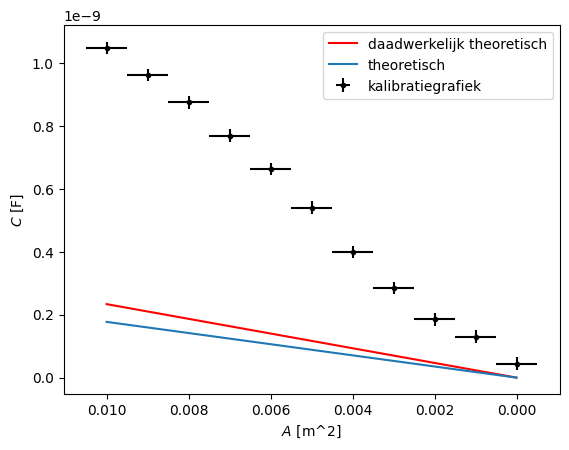

In [28]:
# 3.
A_kal = np.array([0.1,0.09,0.08,0.07,0.06,0.05,0.04,0.03,0.02,0.01,0])*0.1
C_kal = np.array([1047,960.5,874,768,662,540,399,285,185,130,44])*1e-12
A_var = np.linspace(0.01,0,1000) # (m^2) afnemend oppervlakte van 0.01 naar 0.
C_theoretisch_nieuw = idealiteitsfactor*C_niet_ideaal(epsilonr_karton,A_var,d)

plt.figure()
plt.plot(A_var, C_theoretisch_nieuw, "r-", label = "daadwerkelijk theoretisch")
plt.plot(A_var,C_niet_ideaal(epsilonr_karton,A_var,d),label='theoretisch')
plt.errorbar(A_kal,C_kal , xerr=0.0005, yerr=2e-11, fmt = "k.", label = "kalibratiegrafiek")
plt.xlabel("$A$ [m^2]")
plt.ylabel("$C$ [F]")
plt.legend()
plt.gca().invert_xaxis()
plt.show()




##### 6b4
De daadwerkelijk theoretische lijn ligt duidelijk iets boven de theoretische lijn, dit laat zien dat we iets dichterbij de daadwerkelijke waardes komen. Alhoewel dit dichterbij is, is het nog steeds ver van de daadwerkelijke grafiek.

#### Vraag 6c: Niet linear diëlektricum optie 1

Niet alle materialen zijn een lineair diëlektricum. Een aantal van de materialen die sterk niet lineair gedrag vertonen zijn: sponzen, foam & rubber. Als je in je opdracht een materiaal gebruikt heb waarvan je verwacht dat het verband sterk niet lineair is kan dit een hele goede opdracht zijn.
| Materiaal |$\chi_2$   |
| :-------------|:-------------|
| Spons|  |

Als jouw materiaal hier niet tussen staat dan kan je zelf op zoek naar een waarde van $\chi_2$ in de literatuur.

#### Vraag 6c1

1. Leidt het D veld van de condensator af uit de wet van Gauss.
2. Vindt een analytische uitdrukking voor het elektrisch veld in termen van het D veld.

##### Antwoorden 6c 1

*Antwoord vraag 6c 1.*

#### Vraag 6c2

1. Programmeer je oplossingen voor het D en E veld in python, gebruik het D veld uit je fysieke ontwerpopdracht.

Als je het elektrische veld van een vierkante vlakke plaat condensator weet kan je de capaciteit berekenen met de onderstaande formule:
$C = \frac{A
E_z \epsilon_0}{\Delta V}$

2. Plot de capaciteit van het niet lineaire diëlektricum, het theoretische kalibratiegrafiek en de uiteindelijke kalibratiegrafiek van de fysieke ontwerpopdracht.
3. Verklaar verschillen tussen de grafieken.

In [29]:
 # Pas deze code aan zodat jouw opstelling doorgerekend wordt
def E_condensator(x1, x2, D):
    return None

#### Vraag 7

Hoeveel van de afwijking tussen je metingen en je oorspronkelijke voorspelde kalibratiegrafiek wordt verklaard door wat je bij vraag 6 hebt uitgerekend? Kan je een (aantal) elektrisch veld en capaciteit gerelateerde reden(en) verzinnen wat de rest van de afwijking tussen meting en voorspelde kalibratiegrafiek kan verklaren.

##### Antwoorden 7

Door ons antwoord van vraag 6 wordt deze afwijking minimaal verklaard wat laat zien dat dit maar een van de vele factoren is die zorgen dat het theoretische ver afwijkt van het praktische. Andere redenen dat dit kan afwijken zijn: afstand niet nauwkeurig bepaald, geen uniform elektrisch veld en door de capaciteit van de kabels meten we een hogere capaciteit.